## Logistic Regression:

### 1. Data Exploration

In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [184]:
# Load dataset
df1 = pd.read_csv("Titanic_train.csv")
df2 = pd.read_csv("Titanic_test.csv")
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [185]:
df2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [186]:
# EDA
df1.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [187]:
df2.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [188]:
df1.duplicated().sum()

np.int64(0)

In [189]:
df2.duplicated().sum()

np.int64(0)

In [190]:
# features, their types, and summary statistics.
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [191]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [192]:
df.shape


(418, 11)

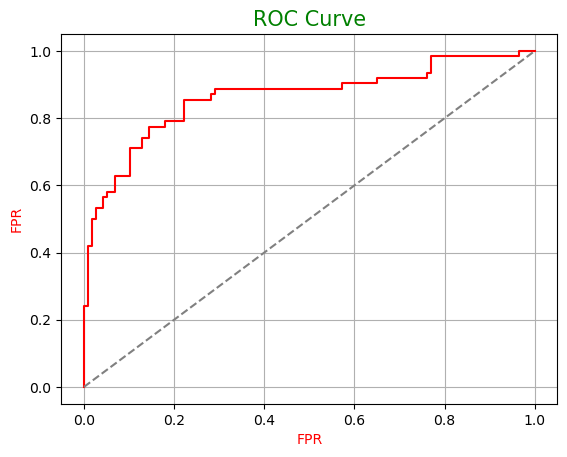

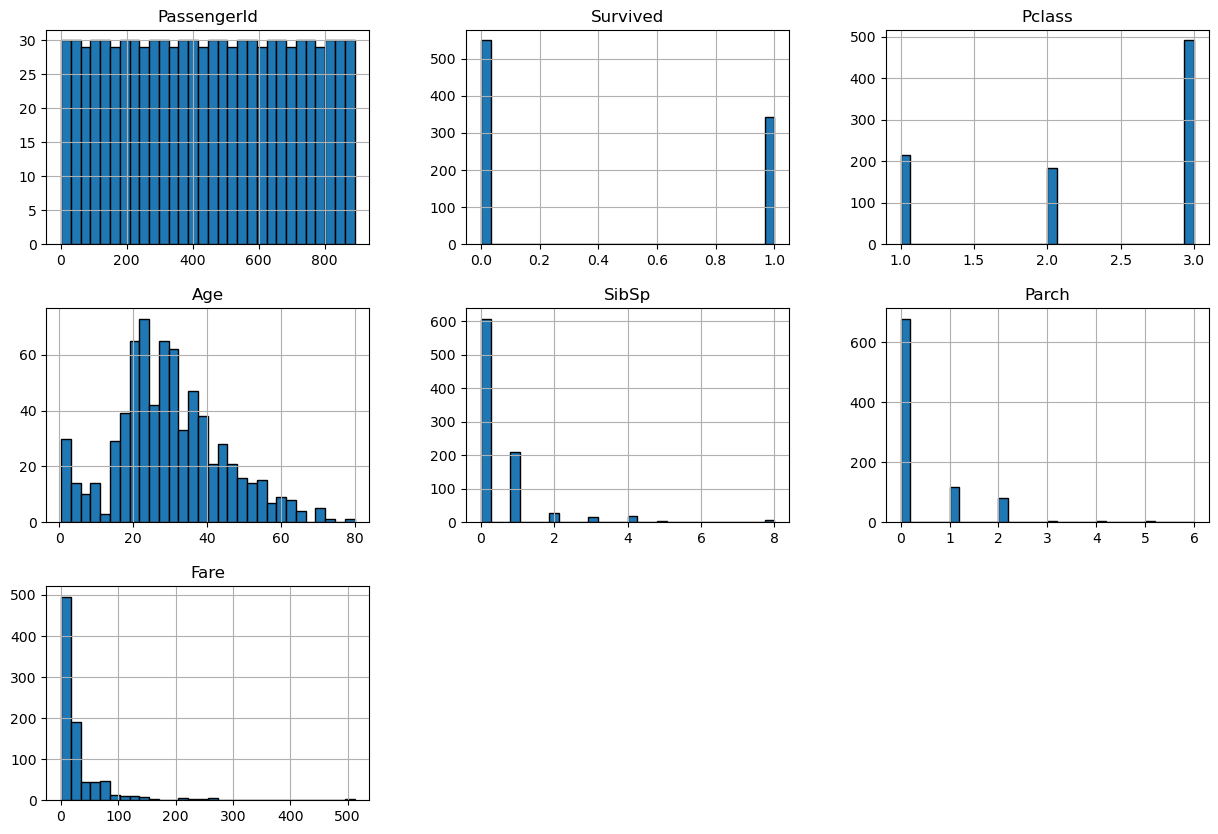

In [193]:
# Visualization - Histogram
df1.hist(bins = 30 , figsize = (15,10) , edgecolor='black')
plt.show()

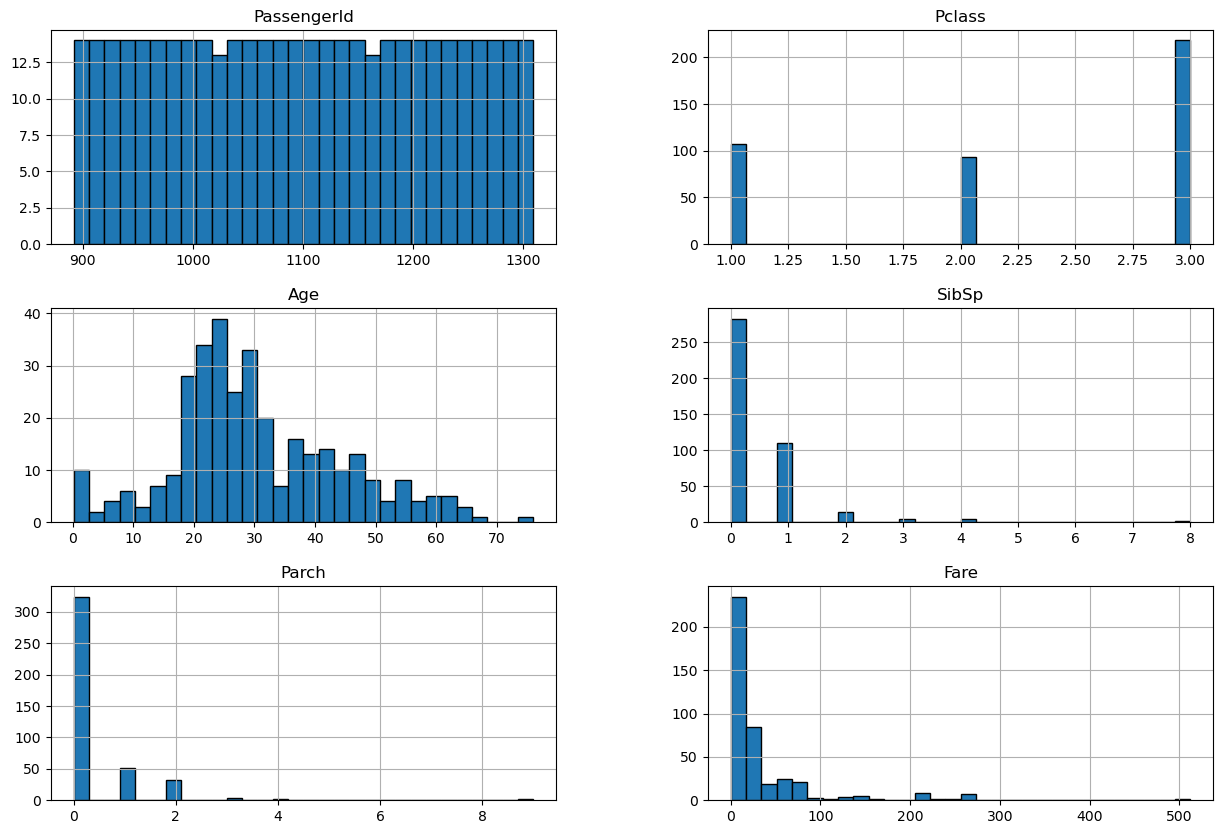

In [194]:
df2.hist(bins = 30 , figsize = (15,10) , edgecolor='black')
plt.show()

In [195]:
df1.select_dtypes(include=['int64','float64'])


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


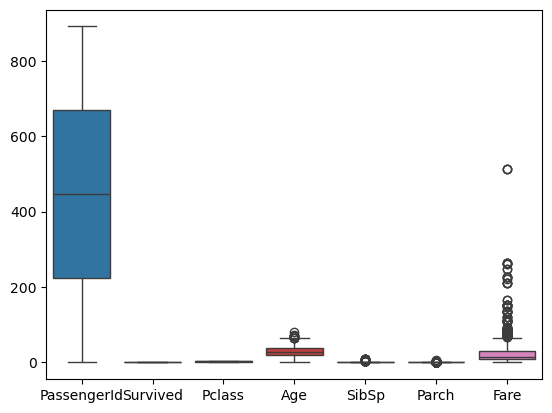

In [196]:
sns.boxplot(data=df1.select_dtypes(include=['int64','float64']))
plt.show()

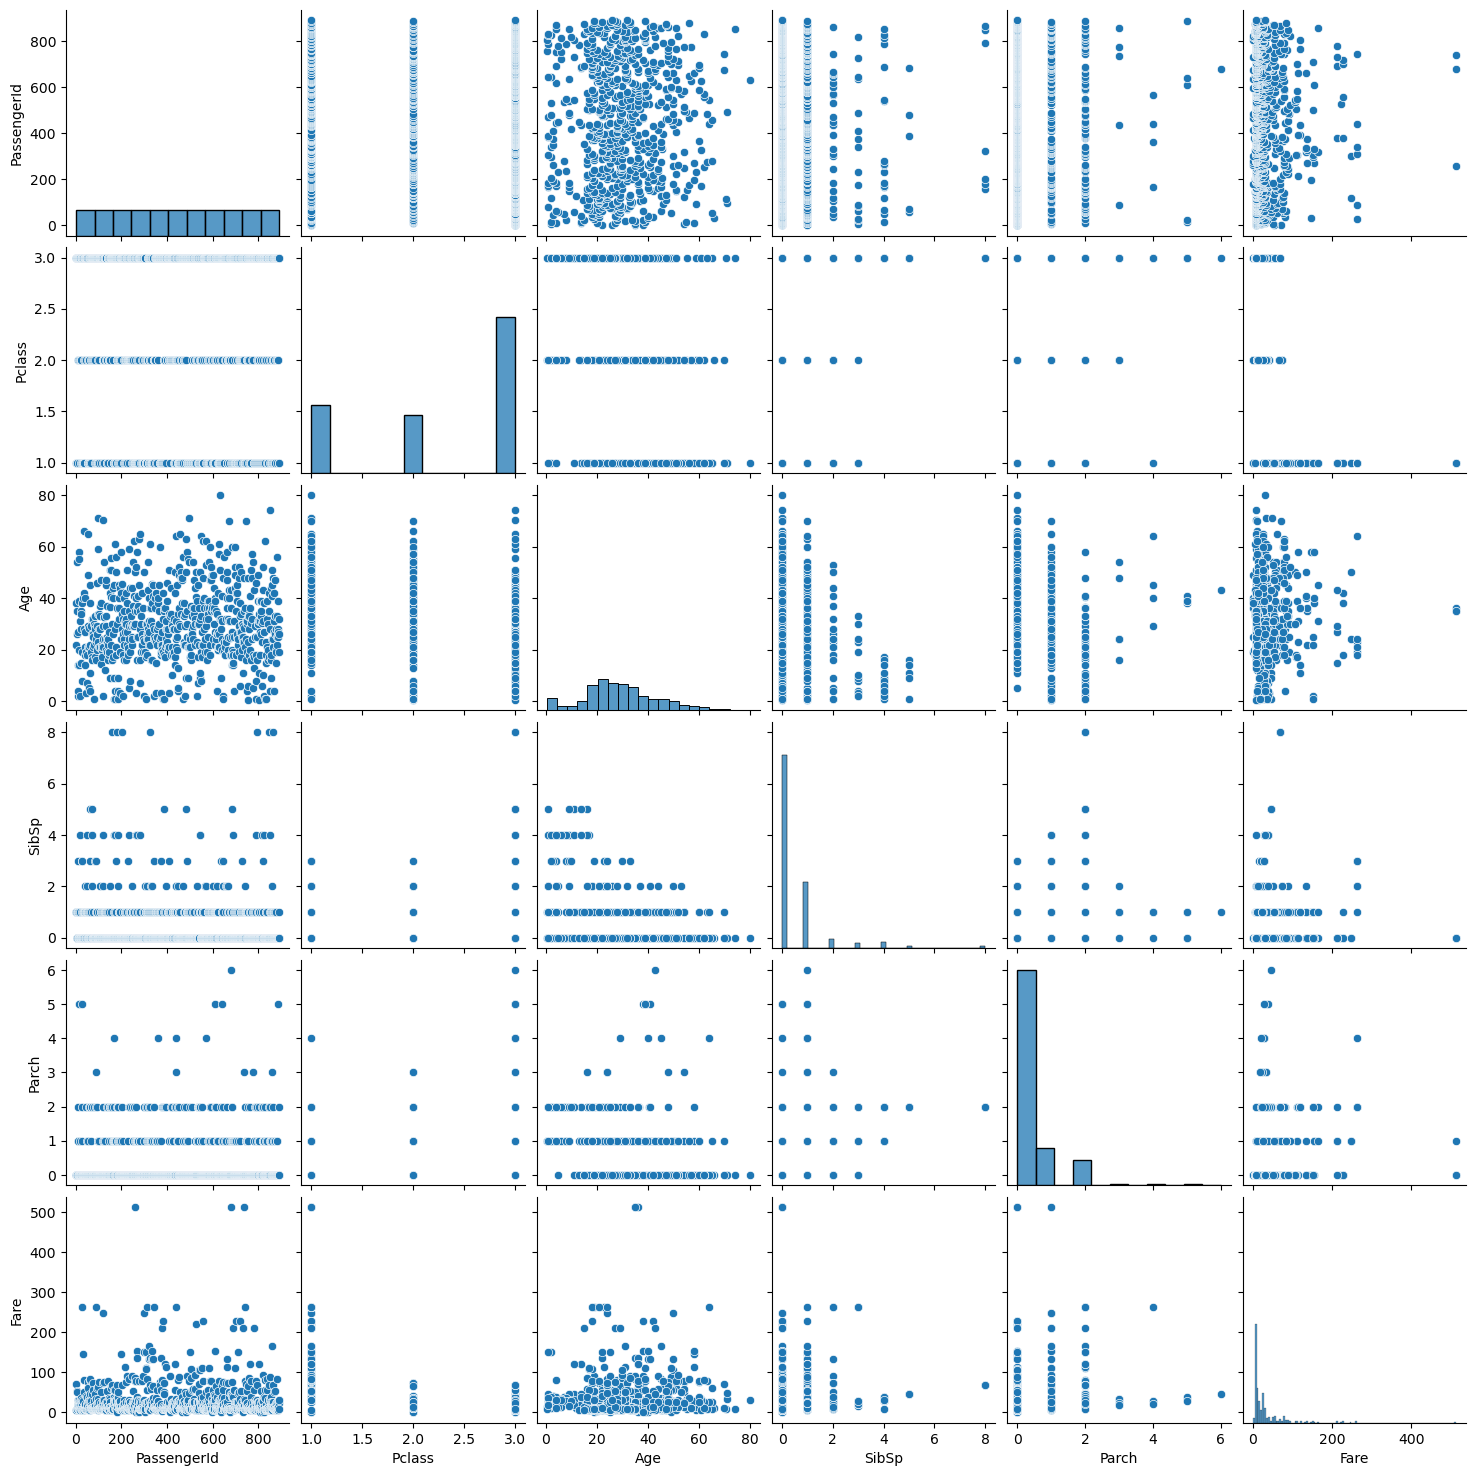

In [197]:
sns.pairplot(df1[['PassengerId','Pclass','Age','SibSp','Parch','Fare']])
plt.show()

In [198]:
df2.select_dtypes(include=['int64','float64'])

,PassengerId,Pclass,Age,SibSp,Parch,Fare
0,892,3,34.5,0,0,7.8292
1,893,3,47.0,1,0,7.0000
2,894,2,62.0,0,0,9.6875
3,895,3,27.0,0,0,8.6625
4,896,3,22.0,1,1,12.2875
...,...,...,...,...,...,...
413,1305,3,NaN,0,0,8.0500
414,1306,1,39.0,0,0,108.9000
415,1307,3,38.5,0,0,7.2500
416,1308,3,NaN,0,0,8.0500


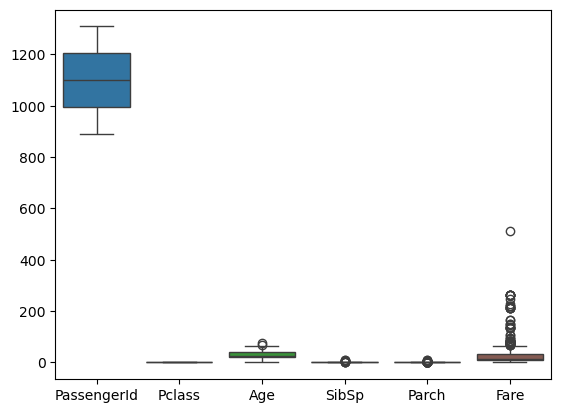

In [199]:
sns.boxplot(data = df2.select_dtypes(include=['int64','float64']))
plt.show()

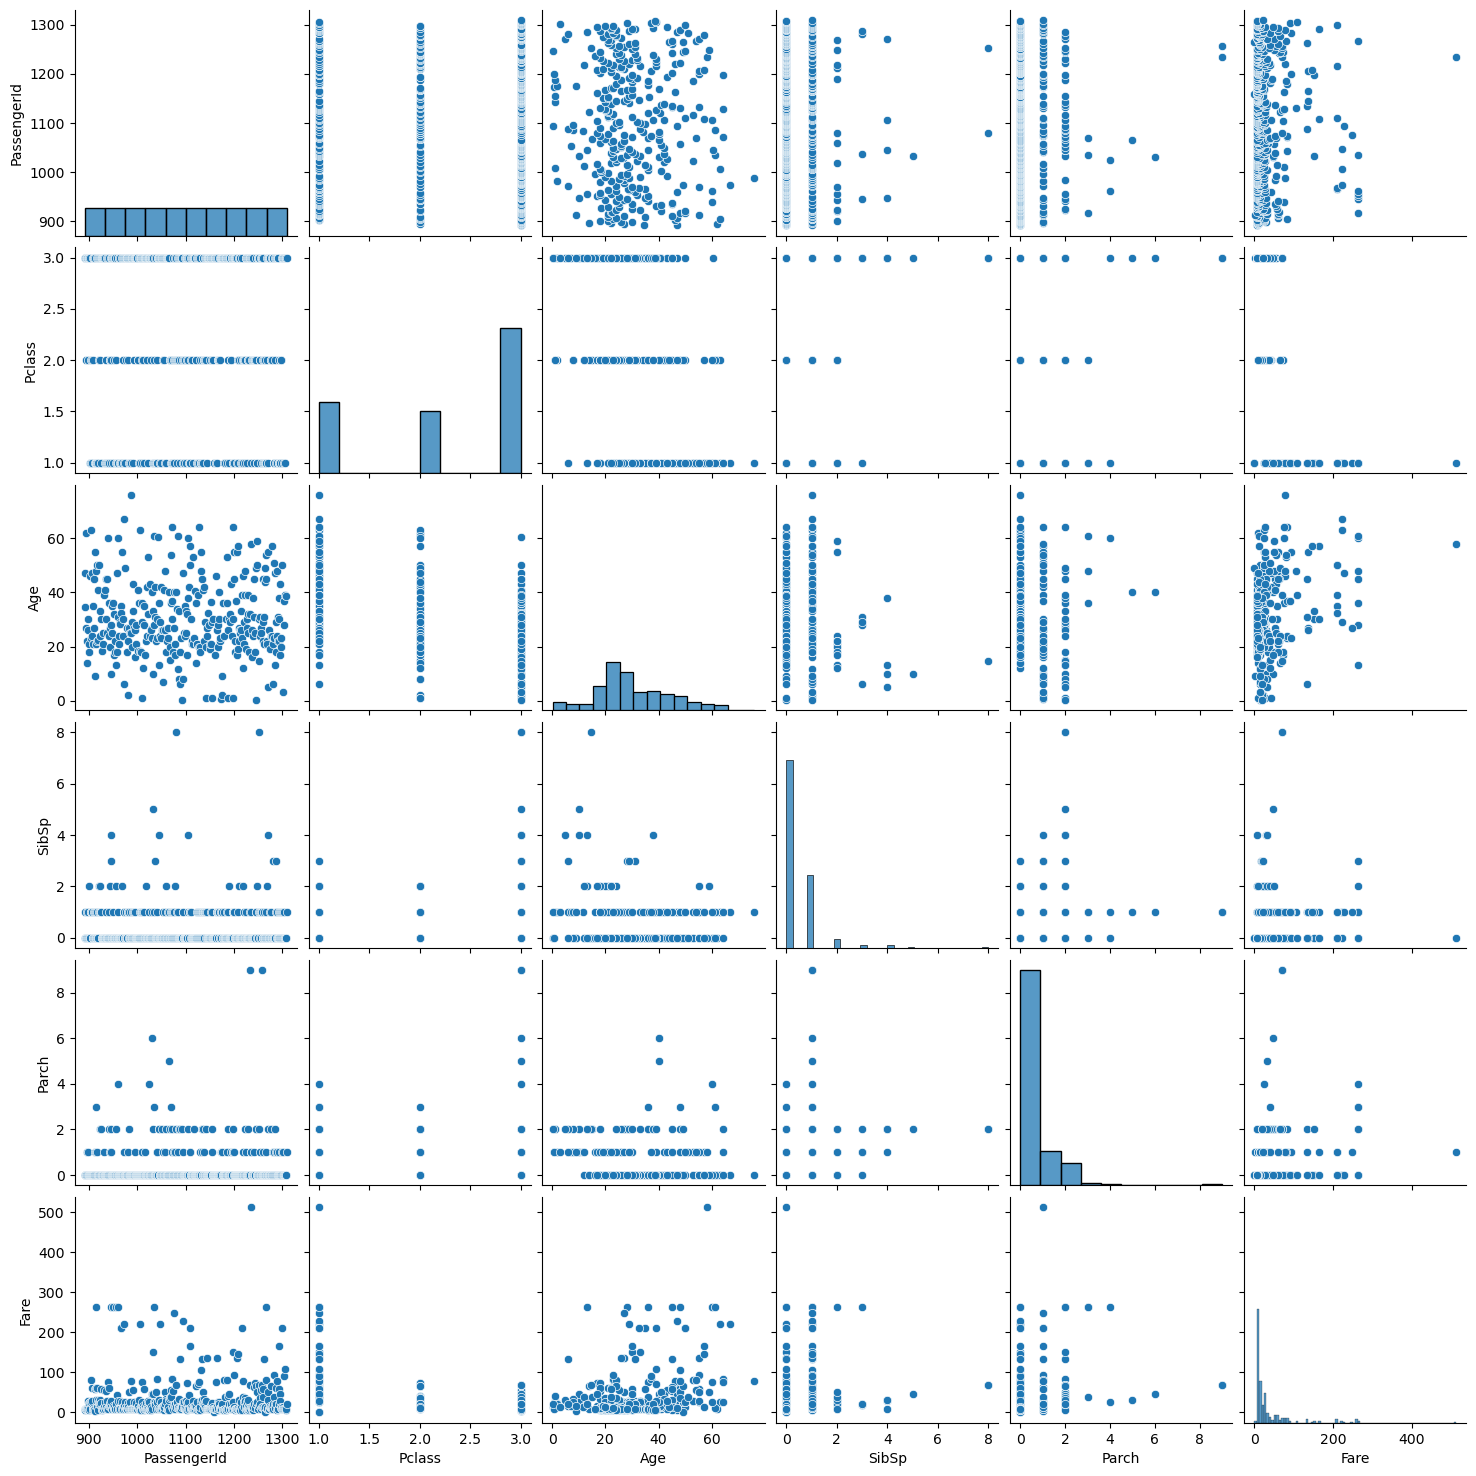

In [200]:
sns.pairplot(df2[['PassengerId','Pclass','Age','SibSp','Parch','Fare']])
plt.show()

### 2.Data Preprocessing ;

In [201]:
# a. Handle missing values (e.g., imputation).
df1.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [202]:
import warnings
warnings.filterwarnings('ignore')
df1['Age'].fillna(df1['Age'].mean(), inplace=True)

In [203]:
df1.drop(columns=['Cabin'], inplace=True)

In [204]:
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [205]:
df1['Embarked'].fillna(df2['Embarked'].mode()[0], inplace=True)

In [206]:
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [207]:
df2.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [208]:
df2['Age'].fillna(df1['Age'].mean(), inplace=True)

In [209]:
df2['Fare'].fillna(df1['Fare'].median(), inplace=True)

In [210]:
df2.drop(columns=['Cabin'], inplace=True)

In [211]:
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [212]:
# b. Encode categorical variables.

df1 = pd.get_dummies(df1, columns = ['Sex','Embarked'], drop_first = True)

In [246]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Sex_male     891 non-null    bool   
 10  Embarked_Q   891 non-null    bool   
 11  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(5), object(2)
memory usage: 65.4+ KB


In [213]:
df1.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [214]:
df2 = pd.get_dummies(df2, columns=['Embarked','Sex'], drop_first=True)

In [215]:
df1.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


### 3. Model Building:

In [216]:
# a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
# define Target and predictor:
Y = df1['Survived']
x = df1.drop(columns=['Survived','Name','Ticket'])
x.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Sex_male     891 non-null    bool   
 7   Embarked_Q   891 non-null    bool   
 8   Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [217]:
# spliting to train and test
from sklearn.model_selection import train_test_split
x_train, x_test , Y_train , Y_test = train_test_split(x,Y,train_size = 0.80, random_state = 10)

In [218]:
print(x_train.shape)
print(x_test.shape)
print(x_train.shape)
print(Y_train.shape)
print(Y_test.shape)

(712, 9)
(179, 9)
(712, 9)
(712,)
(179,)


In [219]:
# standardization (scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [220]:
# Model building
from sklearn.linear_model import LogisticRegression

lreg = LogisticRegression()
# train the model
lreg.fit(x_train, Y_train)

LogisticRegression()

In [221]:
# predict
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report
Y_pred = lreg.predict(x_test)
accuracy_score(Y_test,Y_pred)


0.8212290502793296


### 4. Model Evaluation:


In [222]:
# a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1-score:", f1_score(Y_test, Y_pred))

Accuracy: 0.8212290502793296
Precision: 0.75
Recall: 0.7258064516129032
F1-score: 0.7377049180327869


In [223]:
# b.Visualize the ROC curve.
# probability value
sigmoid = lreg.predict_proba(x_test)[:, 1]

In [224]:

auc_score=roc_auc_score(Y_test,sigmoid)
auc_score

np.float64(0.8624207333884752)

In [225]:
roc_curve(Y_test,sigmoid)

(array([0.        , 0.        , 0.        , 0.00854701, 0.00854701,
        0.01709402, 0.01709402, 0.02564103, 0.02564103, 0.04273504,
        0.04273504, 0.05128205, 0.05128205, 0.06837607, 0.06837607,
        0.1025641 , 0.1025641 , 0.12820513, 0.12820513, 0.14529915,
        0.14529915, 0.17948718, 0.17948718, 0.22222222, 0.22222222,
        0.28205128, 0.28205128, 0.29059829, 0.29059829, 0.57264957,
        0.57264957, 0.64957265, 0.64957265, 0.76068376, 0.76068376,
        0.76923077, 0.76923077, 0.96581197, 0.96581197, 1.        ]),
 array([0.        , 0.01612903, 0.24193548, 0.24193548, 0.41935484,
        0.41935484, 0.5       , 0.5       , 0.53225806, 0.53225806,
        0.56451613, 0.56451613, 0.58064516, 0.58064516, 0.62903226,
        0.62903226, 0.70967742, 0.70967742, 0.74193548, 0.74193548,
        0.77419355, 0.77419355, 0.79032258, 0.79032258, 0.85483871,
        0.85483871, 0.87096774, 0.87096774, 0.88709677, 0.88709677,
        0.90322581, 0.90322581, 0.91935484, 0.

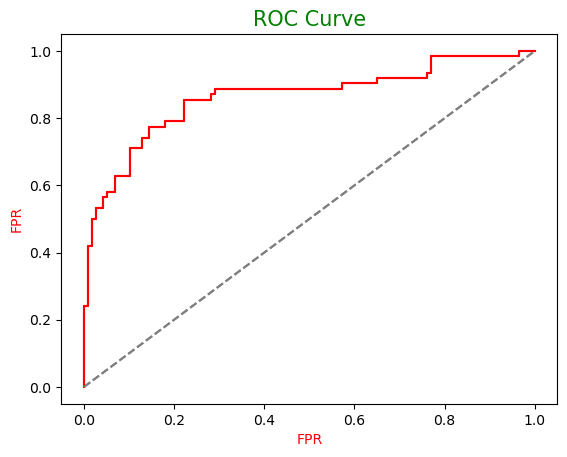

In [245]:
fpr, tpr, thr=roc_curve(Y_test,sigmoid)
plt.plot(fpr,tpr,color='red',lw=1.5,label=f'AUC_SCORE {auc_score:.2f}')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('FPR',color='red',size=10)
plt.ylabel('FPR',color='red',size=10)
plt.title('ROC Curve',color='green',size=15)
plt.grid()
plt.show()

### 5. Interpretation:

In [232]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coefficients)

       Feature  Coefficient
5         Fare     0.074345
0  PassengerId    -0.002221
7   Embarked_Q    -0.042232
4        Parch    -0.104358
8   Embarked_S    -0.272406
2          Age    -0.430783
3        SibSp    -0.496152
1       Pclass    -0.846218
6     Sex_male    -1.297974


In [233]:
# Most significant features: Sex, Pclass, Parch, SibSp

# Moderately influential: Fare, Embarked_S

# Minimal effect: Age, Embarked_Q, PassengerId

### 6. Deployment with Streamlit:


In [238]:
import pickle
file='titanic.pkl'
pickle.dump(lreg,open(file,'wb'))

In [239]:
import pandas as pd
import pickle
import streamlit as st
import warnings
warnings.filterwarnings('ignore')

In [241]:
pickle.dump(lreg, open('titanic.pkl', 'wb'))
st.title("model deployment using logistic regression")

2025-11-02 18:17:19.755 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:17:19.807 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-11-02 18:17:19.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [244]:
import streamlit as st
features = ['Sex','Pclass','Parch','SibSp','Age','Fare','Embarked_Q','Embarked_S','PassengerId']

def user_input_parameters():
    Sex = st.sidebar.selectbox('Select Gender: 0-Male, 1-Female', [0, 1])
    Pclass = st.sidebar.selectbox('Select Passenger Class: 1-First, 2-Second, 3-Third', [1, 2, 3])
    Parch = st.sidebar.number_input('Number of Parents/Children Aboard', min_value=0, max_value=10, value=0)
    SibSp = st.sidebar.number_input('Number of Siblings/Spouses Aboard', min_value=0, max_value=10, value=0)
    Age = st.sidebar.slider('Age', 0, 100, 25)
    Fare = st.sidebar.number_input('Fare', min_value=0.0, max_value=600.0, value=32.0)
    Embarked_Q = st.sidebar.selectbox('Embarked at Q? 0-No, 1-Yes', [0, 1])
    Embarked_S = st.sidebar.selectbox('Embarked at S? 0-No, 1-Yes', [0, 1])
    PassengerId = st.sidebar.number_input('PassengerId', min_value=1, value=1)

    data = {
        'Sex': Sex,
        'Pclass': Pclass,
        'Parch': Parch,
        'SibSp': SibSp,
        'Age': Age,
        'Fare': Fare,
        'Embarked_Q': Embarked_Q,
        'Embarked_S': Embarked_S,
        'PassengerId': PassengerId
    }
    features_df = pd.DataFrame(data, index=[0])
    return features_df

df = user_input_parameters()

# Predict
y_pred = lreg.predict(df)[0]
pred_prob = lreg.predict_proba(df)[0][1]

st.subheader("🎯 Prediction Result:")
st.write("✅ **Survived**" if y_pred == 1 else "❌ **Not Survived**")

st.write(f"**Survival Probability:** {pred_prob:.2f}")

2025-11-02 18:21:53.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.239 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.242 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-02 18:21:53.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

## Interview Questions:


1. What is the difference between precision and recall?

    Precision: Out of all the predicted positives,how many were actually positive?
        - It tells how accurate the positive predictions are.
    Recall: Out of all the actual positives,how many did the model correctly detect?
        - It tells how well the model finds all positive cases.

2. What is cross-validation, and why is it important in binary classification?

    Cross-validation is a technique where the dataset is split into multiple parts(folds),and the model is trained on some parts and tested on the remaining part,repeatedly.

        -It prevents overfitting by testing the model on unseen data many times.
        -It gives a more reliable accuracy measurement than using just one train-test split.
        -It ensures the model generalizes well to new, real-world data.